In [1]:
#importing useful python libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
# Sklearn tools
from sklearn.model_selection import train_test_split,cross_val_score
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix,ConfusionMatrixDisplay,precision_score, recall_score, f1_score
#from sklearn.model_selection import cross_val_score

# XGBoost
from xgboost import XGBClassifier


In [2]:
# dataset
positives=pd.read_csv('lightcurve_features_26.csv')
negatives=pd.read_csv('lightcurve_features_26_negative.csv')

In [3]:
combined = pd.concat([positives,negatives])
# Shuffle the combined dataset
combined = combined.sample(frac=1)#.reset_index(drop=True)
combined.to_parquet("biggie_set_with_all_neg_and_pos.parquet", index=False)

print("Combined and shuffled dataset saved")
print("Total rows:", len(combined))

Combined and shuffled dataset saved
Total rows: 1610


In [4]:
df=pd.read_parquet("biggie_set_with_all_neg_and_pos.parquet")

In [5]:
df

,object,mean,weighted_mean,standard_deviation,median,amplitude,beyond_1_std,cusum,inter_percentile_range_10,kurtosis,...,magnitude_percentage_ratio_20_10,maximum_slope,median_absolute_deviation,median_buffer_range_percentage_10,percent_amplitude,mean_variance,anderson_darling_normal,chi2,skew,stetson_K
0,V2731 Oph,15.821274,15.817911,0.129693,15.831488,0.456778,0.285256,0.165112,0.307883,1.460111,...,0.674872,319.386942,0.083125,0.283120,0.603597,0.008197,5.386825,57.958513,-0.836126,0.771527
1,ZTF18aayvgbc,17.726470,17.684295,0.229726,17.814396,0.739251,0.321292,0.196507,0.610500,-0.332109,...,0.658829,1066.014702,0.124237,0.350301,0.773573,0.012959,52.658819,75.402594,-0.709159,0.847938
2,ZTF18abaclcb,15.849688,15.394642,1.267876,15.524872,2.265728,0.497433,0.272911,3.242108,-1.388859,...,0.814882,2514.148962,1.130001,0.161746,2.499599,0.079994,49.763640,4092.275577,0.009581,0.873203
3,ZTF18aazdiyu,14.395875,14.394708,0.166058,14.326564,0.594457,0.325301,0.269800,0.403300,-0.452040,...,0.721391,832.860721,0.106096,0.403614,0.829474,0.011535,46.572527,126.609834,0.387773,0.862383
4,ZTF19aadotwv,15.732578,15.731969,0.079239,15.752743,0.536561,0.328259,0.165713,0.197709,1.705128,...,0.734943,710.853073,0.051039,0.520140,0.604259,0.005037,47.942206,33.532773,-0.204898,0.824757
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1605,ZTF18aagqgwj,16.317703,16.313961,0.072510,16.308384,0.652972,0.238697,0.260911,0.161474,7.925376,...,0.703009,932.683861,0.047852,0.712831,0.738833,0.004444,30.586187,24.732351,0.532190,0.788607
1606,ZTF18abcohoh,15.690169,15.683411,0.177861,15.683460,0.710431,0.307302,0.249503,0.413878,0.205302,...,0.743642,2643.529235,0.131821,0.188571,0.797108,0.011336,16.883840,72.153012,-0.316785,0.834248
1607,VY For,17.577102,17.028853,0.914877,17.230040,1.484224,0.280000,0.394521,2.470570,-0.614888,...,0.891384,165.691800,0.403616,0.194286,2.222086,0.052049,13.963987,252.971378,0.961304,0.884214
1608,ZTF18abeeiex,16.043872,16.036039,0.165460,15.994022,0.619725,0.219110,0.185220,0.367059,1.931512,...,0.570443,768.246629,0.063496,0.494234,0.704899,0.010313,48.615357,94.871644,0.928853,0.749259


In [6]:
#X
X = df.drop(columns=['object']).values

In [7]:
# object column contains names like 'ZTF18abc...' or non-ZTF names : Binary conversion of objects
y = np.where(df['object'].str.contains('ZTF', case=False),
             -1,   # ZTF → negative
              1)   # non-ZTF → positive

In [8]:
print(np.unique(y))


[-1  1]


In [9]:
#doing this as XGBBOOST can't deal with -1 and 1
y[y == -1] = 0


In [10]:
print(np.unique(y))


[0 1]


In [11]:
SEED = 12

train_sizes = np.arange(0.5, 0.91, 0.1)   # train size
n_estimators = np.arange(50, 201, 20)      # number of trees

results = []

for size in train_sizes:

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        train_size=size,
        shuffle=True,
        random_state=SEED,
        # stratify=y
    )

    # Count classes in this train/test split
    train_positive = np.sum(y_train == 1)
    train_negative = np.sum(y_train == 0)

    test_positive = np.sum(y_test == 1)
    test_negative = np.sum(y_test == 0)

    for n in n_estimators:

        # XGBoost model
        model = XGBClassifier(
            n_estimators=n,
            max_depth=10,
            learning_rate=0.3,
            eval_metric='logloss',
            random_state=SEED
        )

        # Model fitting
        model.fit(X_train, y_train)

        # Prediction
        y_pred = model.predict(X_test)

        # Evaluation
        acc = accuracy_score(y_test, y_pred)
        precision = precision_score(y_test, y_pred, pos_label=1)
        recall = recall_score(y_test, y_pred, pos_label=1)
        f1 = f1_score(y_test, y_pred, pos_label=1)

        # Store results
        results.append({
            "train_size": size,
            "n_estimators": n,
            "max_depth": 10,
            "learning_rate": 0.3,

            # Class counts
            "train_positive": train_positive,
            "train_negative": train_negative,
            "test_positive": test_positive,
            "test_negative": test_negative,

            # Performance
            "accuracy": acc,
            "precision": precision,
            "recall": recall,
            "f1_score": f1
        })

results_df = pd.DataFrame(results)

In [12]:
#check
results_df

,train_size,n_estimators,max_depth,learning_rate,train_positive,train_negative,test_positive,test_negative,accuracy,precision,recall,f1_score
0,0.5,50,10,0.3,65,740,74,731,0.975155,0.875000,0.851351,0.863014
1,0.5,70,10,0.3,65,740,74,731,0.977640,0.888889,0.864865,0.876712
2,0.5,90,10,0.3,65,740,74,731,0.976398,0.887324,0.851351,0.868966
3,0.5,110,10,0.3,65,740,74,731,0.976398,0.887324,0.851351,0.868966
4,0.5,130,10,0.3,65,740,74,731,0.976398,0.887324,0.851351,0.868966
5,0.5,150,10,0.3,65,740,74,731,0.975155,0.875000,0.851351,0.863014
6,0.5,170,10,0.3,65,740,74,731,0.975155,0.875000,0.851351,0.863014
7,0.5,190,10,0.3,65,740,74,731,0.975155,0.875000,0.851351,0.863014
8,0.6,50,10,0.3,76,890,63,581,0.972050,0.894737,0.809524,0.850000
9,0.6,70,10,0.3,76,890,63,581,0.975155,0.912281,0.825397,0.866667


In [13]:
# Find best configuration based on precision
best_row = results_df.loc[results_df["precision"].idxmax()]

best_train_size = best_row["train_size"]
best_n_estimators = best_row["n_estimators"]
best_max_depth = best_row["max_depth"]
best_learning_rate = best_row["learning_rate"]

# Training and test class counts
best_train_positive = best_row["train_positive"]
best_train_negative = best_row["train_negative"]
best_test_positive = best_row["test_positive"]
best_test_negative = best_row["test_negative"]

# Performance metrics
best_accuracy = best_row["accuracy"]
best_precision = best_row["precision"]
best_recall = best_row["recall"]
best_f1 = best_row["f1_score"]

print("Best configuration based on precision:")
print(f"Train size        : {best_train_size}")
print(f"n_estimators      : {best_n_estimators}")
print(f"max_depth         : {best_max_depth}")
print(f"learning_rate     : {best_learning_rate}")

print("\nTraining set:")
print(f"CV (positive)     : {int(best_train_positive)}")
print(f"Unknown (negative): {int(best_train_negative)}")
print(f"Total             : {int(best_train_positive + best_train_negative)}")

print("\nTest set:")
print(f"CV (positive)     : {int(best_test_positive)}")
print(f"Unknown (negative): {int(best_test_negative)}")
print(f"Total             : {int(best_test_positive + best_test_negative)}")

print("\nTest performance:")
print(f"Accuracy           : {best_accuracy:.4f}")
print(f"Precision          : {best_precision:.4f}")
print(f"Recall             : {best_recall:.4f}")
print(f"F1-score           : {best_f1:.4f}")

# Save best configuration
best_row.to_frame().T.to_csv(
    "best_configuration_RS_12.csv",
    index=False
)

Best configuration based on precision:
Train size        : 0.6
n_estimators      : 130.0
max_depth         : 10.0
learning_rate     : 0.3

Training set:
CV (positive)     : 76
Unknown (negative): 890
Total             : 966

Test set:
CV (positive)     : 63
Unknown (negative): 581
Total             : 644

Test performance:
Accuracy           : 0.9736
Precision          : 0.9259
Recall             : 0.7937
F1-score           : 0.8547


In [14]:
#train the best model
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    train_size=best_train_size,
    #stratify=y,
    random_state=12
)
#best model with best parameters
best_model = XGBClassifier(
    n_estimators=int(best_n_estimators),
    max_depth=int(best_max_depth),
    learning_rate=float(best_learning_rate),
    eval_metric='logloss',
    n_jobs=-1
)
#fit best model
best_model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.3, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=10, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=130, n_jobs=-1,
              num_parallel_tree=None, ...)

In [15]:
#predict model
y_pred = best_model.predict(X_test)
#print(y_pred)


In [16]:
#accuracy
print("Accuracy:", accuracy_score(y_test, y_pred))
#precision
print("Precision:", precision_score(y_test, y_pred))


Accuracy: 0.9736024844720497
Precision: 0.9259259259259259


In [17]:
probs = best_model.predict_proba(X_test)
#print('probs',probs)

Confusion matrix (raw counts):
[[577   4]
 [ 13  50]]


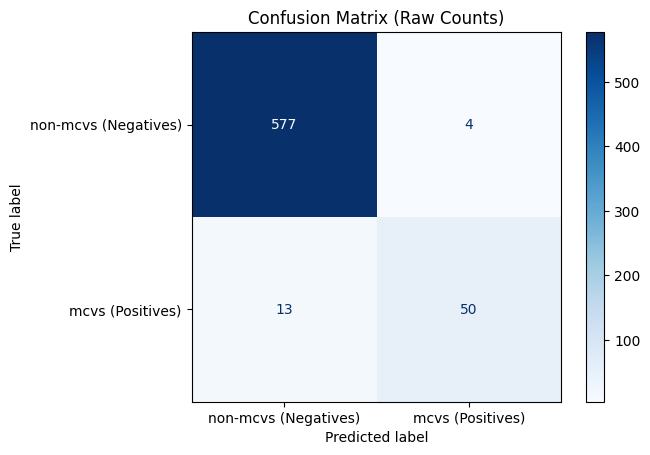

In [18]:
# For best model CONFUSION MATRIX + TP / TN / FP / FN IDENTIFICATION
# Class labels for clarity
class_names = ["non-mcvs (Negatives)", "mcvs (Positives)"]

# Plot confusion matrix (raw counts)
disp = ConfusionMatrixDisplay.from_estimator(
   best_model,
    X_test,
    y_test,
    display_labels=class_names,
    cmap=plt.cm.Blues #heatmap
)

disp.ax_.set_title("Confusion Matrix (Raw Counts)")
print("Confusion matrix (raw counts):")
print(disp.confusion_matrix)

plt.show()


# Extract TN, FP, FN, TP explicitly
# Label convention used in  code:
#   0 :ZTF names (negative, non-CV)
#   +1 :non-ZTF names (positive, CV)

cm = confusion_matrix(y_test, best_model.predict(X_test), labels=[0, 1])

TN, FP, FN, TP = cm.ravel()

In [19]:
#saving the best model
joblib.dump(best_model, "cv_classifier_best_model_12.pkl")

['cv_classifier_best_model_12.pkl']

In [20]:
#from this cell our prev work
# last used hyperparameters
train_size = 0.70
n_estimators = 50
#oter parameters were not varied
# Final train-test split
X_train_prev, X_test_prev, y_train_prev, y_test_prev = train_test_split(
    X,
    y,
    train_size=0.70,
    shuffle=True,
    random_state=12
)

# Train final model
final_model =  XGBClassifier(
    n_estimators=50,
    n_jobs=-1,
    learning_rate=0.1, #Learning rate shrinks the contribution of each tree,Values must be in the range [0.0, inf),values by default float, default=0.1
    max_depth=3, #max_depthint or None, default=3
    eval_metric='logloss',
    random_state=12
)

final_model.fit(X_train_prev, y_train_prev)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=3, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=50, n_jobs=-1,
              num_parallel_tree=None, ...)

In [21]:
#training set
final_model.fit(X_train_prev, y_train_prev)

print("Model trained successfully")


Model trained successfully


In [22]:
#predict model
y_pred = final_model.predict(X_test_prev)
print(y_pred)


[1 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 1 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 1 0 1 0 0
 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0
 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 1 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0
 0 1 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 1 0 0 0 0
 1 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 1 0 1 0 0 0 0 0 0 0 0 0 0 0 0 1 1 0 0 0 0 0 0 0 0 0 1 1 0 0 0
 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 1 1 0 0 0 1 1 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 1 0 0 0 0 0 1 0 0 0 0 0 0 1 0 0 0 0 0 0
 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0
 0 1]


In [23]:
#accuracy
print("Accuracy:", accuracy_score(y_test_prev, y_pred))


Accuracy: 0.9751552795031055


In [24]:
probs = best_model.predict_proba(X_test_prev)
print('probs',probs)

probs [[2.34657526e-02 9.76534247e-01]
 [9.99927223e-01 7.27780935e-05]
 [9.99944150e-01 5.58420361e-05]
 [9.99804437e-01 1.95564091e-04]
 [9.99957442e-01 4.25474973e-05]
 [9.99847591e-01 1.52424225e-04]
 [9.99977648e-01 2.23579045e-05]
 [9.99660254e-01 3.39735037e-04]
 [9.99975085e-01 2.49168770e-05]
 [9.99249935e-01 7.50067353e-04]
 [3.27660024e-01 6.72339976e-01]
 [2.18690038e-02 9.78130996e-01]
 [9.99987245e-01 1.27737258e-05]
 [9.83811617e-01 1.61883533e-02]
 [9.99297738e-01 7.02262041e-04]
 [9.99891400e-01 1.08626227e-04]
 [9.99031425e-01 9.68546956e-04]
 [9.99934077e-01 6.59349680e-05]
 [9.99353349e-01 6.46648696e-04]
 [9.99954343e-01 4.56775779e-05]
 [9.89288568e-01 1.07114436e-02]
 [9.69279289e-01 3.07207257e-02]
 [9.99771416e-01 2.28582954e-04]
 [9.97857928e-01 2.14207987e-03]
 [9.99975264e-01 2.47642711e-05]
 [9.99983430e-01 1.65548827e-05]
 [1.57495737e-02 9.84250426e-01]
 [9.94695723e-01 5.30429184e-03]
 [9.99948263e-01 5.17447006e-05]
 [9.99862671e-01 1.37350711e-04]
 [9.

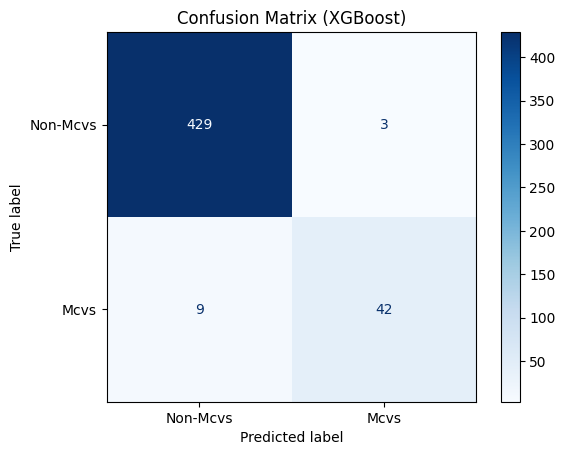

In [25]:
# --- Confusion Matrix ---
cm = confusion_matrix(y_test_prev, y_pred, labels=[0, 1])

class_names = ["Non-Mcvs", "Mcvs"]

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)

disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix (XGBoost)")
# Save the figure to current directory
#plt.savefig('confusion matrix_plot.png', dpi=300, bbox_inches='tight')
plt.show()

In [26]:
#extract TP, TN, FP, FN
TN, FP, FN, TP = cm.ravel()
print("TN:", TN, "FP:", FP, "FN:", FN, "TP:", TP)

TN: 429 FP: 3 FN: 9 TP: 42


In [27]:
#saving the final model
joblib.dump(final_model, "cv_classifier_xgb_boost_biggie_set_12.pkl")

['cv_classifier_xgb_boost_biggie_set_12.pkl']